# **YOLOV1 plots explanation**

In [6]:
from PIL import Image
from pathlib import Path
from collections import Counter

import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

path = Path.cwd()
while not (path / "computer_vision").exists():
    path = path.parent

sys.path.append(str(path))

datasets_path = "/home/otokonokage/Documents/github/dataset/computer_vision/"

In [7]:
from computer_vision.datasets import vocdetection

dataset_path, annotations, weights, num_classes, categories, dataset_name, dataset_box_format, mode, dataset_normalized = vocdetection(datasets_path, "train", year="2012")
reversed_categories = dict([(id, label) for label, id in categories.items()])
print(dataset_box_format)

train pascalvoc2012: 100%|██████████| 17125/17125 [00:01<00:00, 14414.10it/s]

xyxy


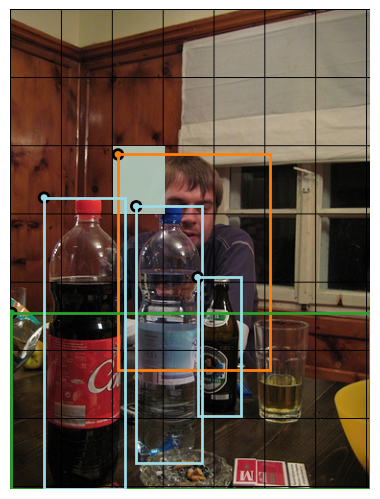

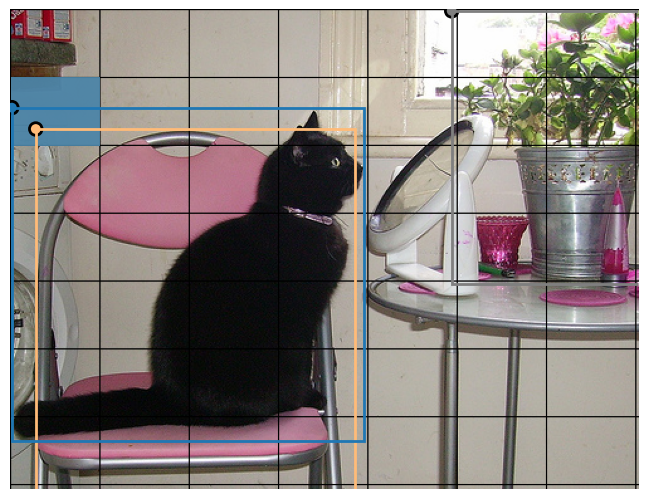

In [8]:
cmap = plt.get_cmap('tab20')

colors = dict([(category, cmap(i / num_classes)) for i, category in enumerate(reversed_categories)])
keys = list(annotations["bboxes"].keys())
keys = ["2009_002579", "2008_003726"]
for key in keys:
    fig, ax = plt.subplots(1, 1)

    image = np.array(Image.open(os.path.join(dataset_path, f"{key}.jpg"), "r"))
    H, W, _ = image.shape

    dw, dh = image.shape[0] // 7, image.shape[1] // 7
    grid_color = [0, 0, 0]

    image[:,::dh,:] = grid_color
    image[::dw,:,:] = grid_color
    ax.imshow(image)
    ax.axis("off")

    rect_to_display = []

    for bbox in annotations["bboxes"][f"{key}"]:
        label = bbox[0]
        bbox = bbox[1:]
        i, j = math.floor((bbox[1] / H) * 7), math.floor((bbox[0] / W) * 7)
        rect_to_display.append((i,j))

    rect_counter = Counter(rect_to_display)

    for bbox in annotations["bboxes"][f"{key}"]:
        label = bbox[0]
        bbox = bbox[1:]

        i, j = math.floor((bbox[1] / H) * 7), math.floor((bbox[0] / W) * 7)
        if rect_counter[(i,j)] == 1:
            continue

        x, y = j * (W / 7), i * (H / 7)
        rect = patches.Rectangle((math.floor(x), math.floor(y)), W / 7, H / 7, linewidth=0, facecolor=colors[label], edgecolor=colors[label], alpha=0.75)
        ax.add_patch(rect)

    for bbox in annotations["bboxes"][f"{key}"]:
        label = bbox[0]
        bbox = bbox[1:]

        circle = patches.Circle((bbox[0], bbox[1]), radius=5, linewidth=2, edgecolor="black", facecolor=colors[label])
        ax.add_patch(circle)
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
        ax.add_patch(rect)

    fig.tight_layout(pad=0, h_pad=0, w_pad=0)
    plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{key}"), bbox_inches='tight')
plt.show()

448 608


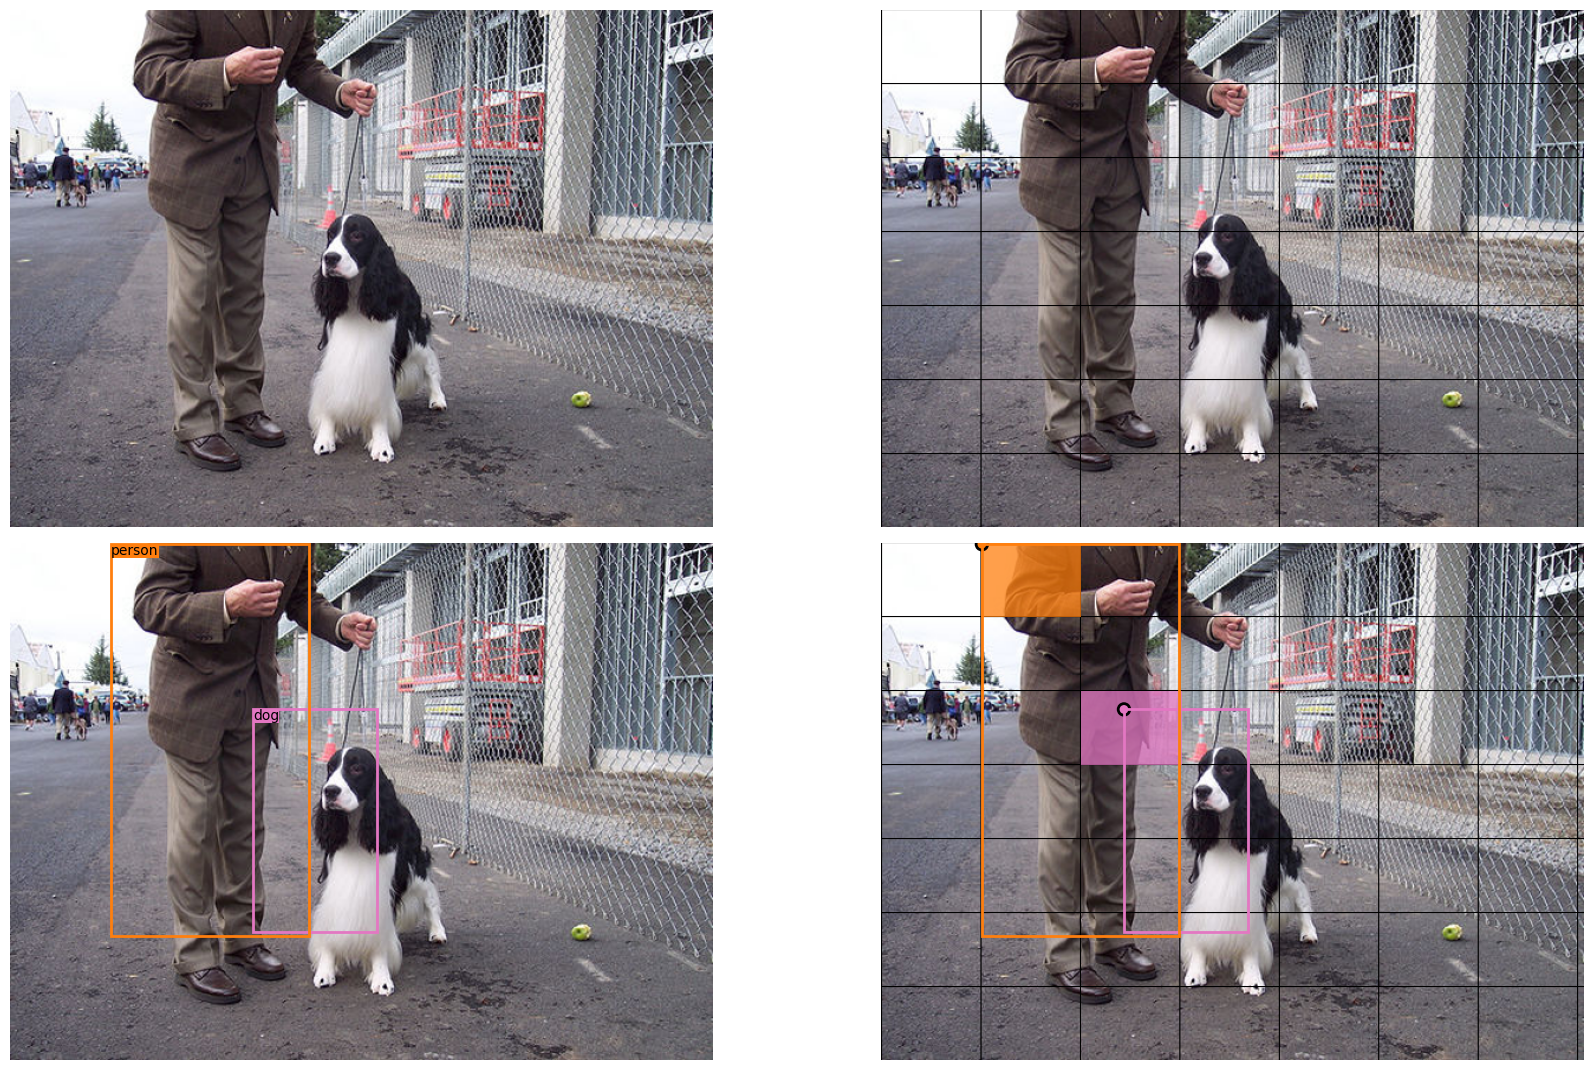

In [9]:
cmap = plt.get_cmap('tab20')

colors = dict([(category, cmap(i / num_classes)) for i, category in enumerate(reversed_categories)])

fig, ax = plt.subplots(2, 2, figsize=(19.2, 10.8))

image = np.array(Image.open(os.path.join(dataset_path, "2008_001182.jpg"), "r").resize((608, 448)))
H, W, _ = image.shape
print(H, W)
dw, dh = int(H / 7), int(W / 7)
grid_color = [0,0,0]

img = image.copy()
for (row, col) in [(0, 1), (1, 1)]:
    img[:,::dh,:] = grid_color
    img[::dw,:,:] = grid_color
    ax[row][col].imshow(img)

for bbox in annotations["bboxes"]["2008_001182"]:
    label = bbox[0]
    bbox = bbox[1:]
    ax[1][0].text(bbox[0], bbox[1], reversed_categories[label], ha='left', va='top', bbox=dict(facecolor=colors[label], edgecolor="none", pad=0))
    x, y = math.floor((bbox[0] / W) * 7) * (W / 7), math.floor((bbox[1] / H) * 7) * (H / 7)
    rect = patches.Rectangle((math.floor(x), math.floor(y)), W / 7, H / 7, linewidth=0, facecolor=colors[label], edgecolor=colors[label], alpha=0.75)
    ax[1][1].add_patch(rect)

for i in range(2):
    for j in range(2):
        if (i == 0 and j == 1) or (i == 1 and j == 1):
            ax[i][j].axis("off")
            continue
        ax[i][j].imshow(image)
        ax[i][j].axis("off")

for (row, col) in [(1, 0), (1, 1)]:
    for bbox in annotations["bboxes"]["2008_001182"]:
        label = bbox[0]
        bbox = bbox[1:]
        if (row, col) == (1, 1):
            circle = patches.Circle((bbox[0], bbox[1]), radius=5, linewidth=2, edgecolor="black", facecolor=colors[label])
            ax[row][col].add_patch(circle)
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
        ax[row][col].add_patch(rect)
    
fig.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"yolov1_explanation"), bbox_inches="tight")
plt.show()

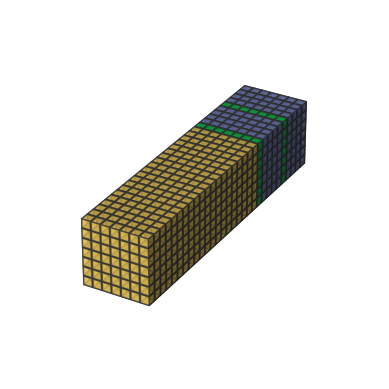

In [10]:
def explode(data):
    size = np.array(data.shape)*2
    data_e = np.zeros(size - 1, dtype=data.dtype)
    data_e[::2, ::2, ::2] = data
    return data_e

C = 20
B = 2
Sh = 7
Sw = 7
n_voxels = np.zeros((Sh, C + (B * 5), Sw), dtype=int)
for i in range(n_voxels.shape[0]):
    for j in range(n_voxels.shape[2]):
        for k in range(n_voxels.shape[1]):
            if k > 19:
                if k % 5 == 0:
                    n_voxels[i, k, j] = 1
                else:
                    n_voxels[i, k, j] = 2
            else:
                n_voxels[i, k, j] = 0

color1 = "#FFD65DC0"
color2 = "#09D24CC0"
color3 = '#7A88CCC0'
edgecolor = "#3F3F3FC0"
                
colors = np.array([color1, color2, color3])
facecolors = colors[n_voxels]

edgecolors_map = np.array([edgecolor]*3)
edgecolors = edgecolors_map[n_voxels]
filled = np.ones(n_voxels.shape)

# upscale the above voxel image, leaving gaps
filled_2 = explode(filled)
fcolors_2 = explode(facecolors)
ecolors_2 = explode(edgecolors)

# Shrink the gaps
x, y, z = np.indices(np.array(filled_2.shape) + 1).astype(float) // 2
x[0::2, :, :] += 0.05
y[:, 0::2, :] += 0.05
z[:, :, 0::2] += 0.05
x[1::2, :, :] += 0.95
y[:, 1::2, :] += 0.95
z[:, :, 1::2] += 0.95

ax = plt.figure().add_subplot(projection='3d')
ax.voxels(x, y, z, filled_2, facecolors=fcolors_2, edgecolors=ecolors_2)
ax.set_aspect('equal')
ax.axis("off")
plt.show()